# Preprocessing & Dimensionality Reduction

## Overview
Raw RNA-Seq expression data requires several preprocessing steps before it is suitable
for clustering algorithms. This notebook applies a standard bioinformatics pipeline and
then uses Principal Component Analysis (PCA) to reduce the dimensionality from ~20 000
genes to a compact set of components that still captures most of the variance.

## Why each step is necessary

| Step | Reason |
|---|---|
| **Remove zero-variance genes** | Genes with zero variance across all samples carry no information and would dilute distance computations in PCA and clustering. |
| **log1p transform** | RNA-Seq counts follow a heavily right-skewed distribution with many zeros. `log1p(x) = log(1 + x)` compresses the dynamic range and makes the distribution more symmetric, which improves the behaviour of StandardScaler and PCA. |
| **StandardScaler** | PCA is sensitive to the scale of each feature. Standardising to zero mean and unit variance ensures that high-expression genes do not dominate the principal components simply because of their magnitude. |
| **PCA** | With 20 000+ genes the feature space is far too large for clustering. PCA finds the directions of maximum variance and projects the data onto them. Retaining enough components to explain 95% of variance gives a compact representation that discards noise while preserving the biologically meaningful signal. |

## Inputs
- `data/data.csv` — raw gene expression matrix (801 samples × 20 531 genes)
- `data/labels.csv` — cancer subtype labels (held out, used only for visualisation)

## Outputs
- `models/scaler.joblib` — fitted `StandardScaler` (reused by the Streamlit app)
- `models/pca.joblib` — fitted `PCA` object (reused by the Streamlit app)
- `data/X_pca.csv` — PCA-reduced feature matrix used by downstream notebooks
- `data/kept_genes.csv` — list of genes remaining after zero-variance filtering
- `reports/figures/log1p_transform.png`
- `reports/figures/pca_explained_variance.png`
- `reports/figures/pca_2d_projection.png`

## 0. Imports

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

DATA_PATH    = "../data/data.csv"
LABELS_PATH  = "../data/labels.csv"
MODELS_DIR   = "../models"
DATA_OUT_DIR = "../data"
FIGURES_DIR  = "../reports/figures"

os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

## 1. Load Data

In [18]:
X      = pd.read_csv(DATA_PATH, index_col=0)
labels = pd.read_csv(LABELS_PATH, index_col=0)["Class"]

print(f"Loaded : {X.shape[0]} samples x {X.shape[1]} genes")

Loaded : 801 samples x 20531 genes


## 2. Remove Zero-Variance Genes

In [19]:
gene_var   = X.var(axis=0)
zero_var   = gene_var[gene_var == 0].index
X_filtered = X.drop(columns=zero_var)

print(f"Removed {len(zero_var)} zero-variance genes")
print(f"Remaining : {X_filtered.shape[1]} genes")

Removed 267 zero-variance genes
Remaining : 20264 genes


## 3. Log1p Transform

RNA-Seq expression values are right-skewed with many zeros. `log1p` compresses the dynamic range and brings the distribution closer to normal without undefined values at zero.

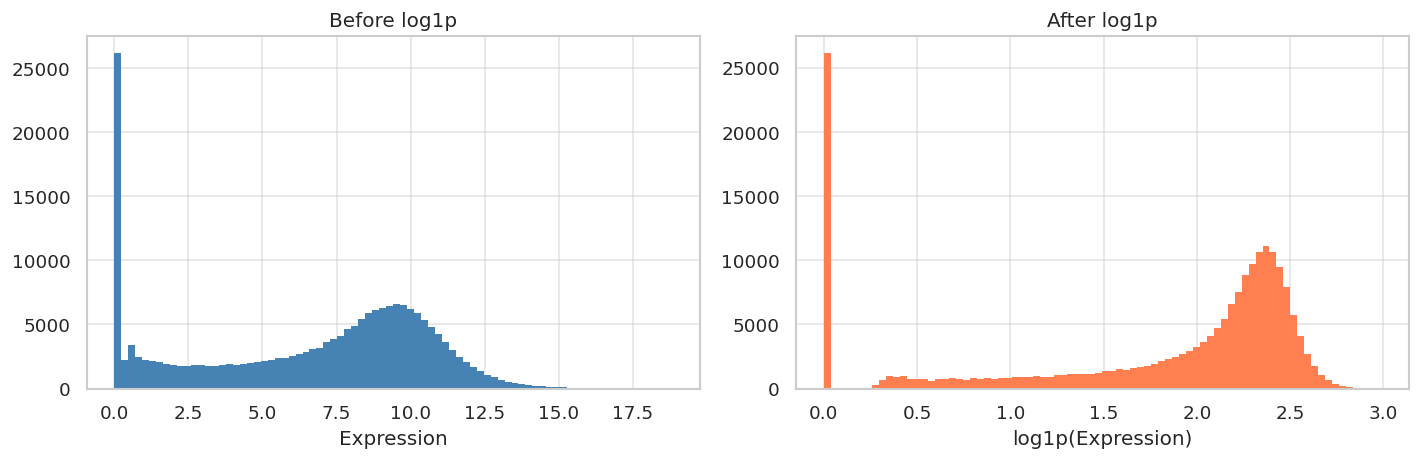

Post-transform mean : 1.7569
Post-transform std  : 0.8576


In [20]:
X_log = np.log1p(X_filtered)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample_raw = X_filtered.values.flatten()
sample_raw = sample_raw[np.random.choice(len(sample_raw), 200_000, replace=False)]
sample_log = np.log1p(sample_raw)

axes[0].hist(sample_raw, bins=80, color="steelblue", edgecolor="none")
axes[0].set_title("Before log1p")
axes[0].set_xlabel("Expression")

axes[1].hist(sample_log, bins=80, color="coral", edgecolor="none")
axes[1].set_title("After log1p")
axes[1].set_xlabel("log1p(Expression)")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/log1p_transform.png")
plt.show()

print(f"Post-transform mean : {X_log.values.mean():.4f}")
print(f"Post-transform std  : {X_log.values.std():.4f}")

## 4. Standardize (Zero Mean, Unit Variance)

In [21]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print(f"Scaled matrix shape : {X_scaled.shape}")
print(f"Mean (should be ~0) : {X_scaled.mean():.6f}")
print(f"Std  (should be ~1) : {X_scaled.std():.6f}")

Scaled matrix shape : (801, 20264)
Mean (should be ~0) : 0.000000
Std  (should be ~1) : 1.000000


## 5. PCA — Explained Variance Analysis

In [22]:
# Fit full PCA to inspect the explained-variance curve
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Components needed to reach common thresholds
for thresh in [0.80, 0.90, 0.95, 0.99]:
    n = int(np.searchsorted(cumvar, thresh)) + 1
    print(f"{thresh*100:.0f}% variance explained by {n} components")

80% variance explained by 196 components
90% variance explained by 392 components
95% variance explained by 548 components
99% variance explained by 732 components


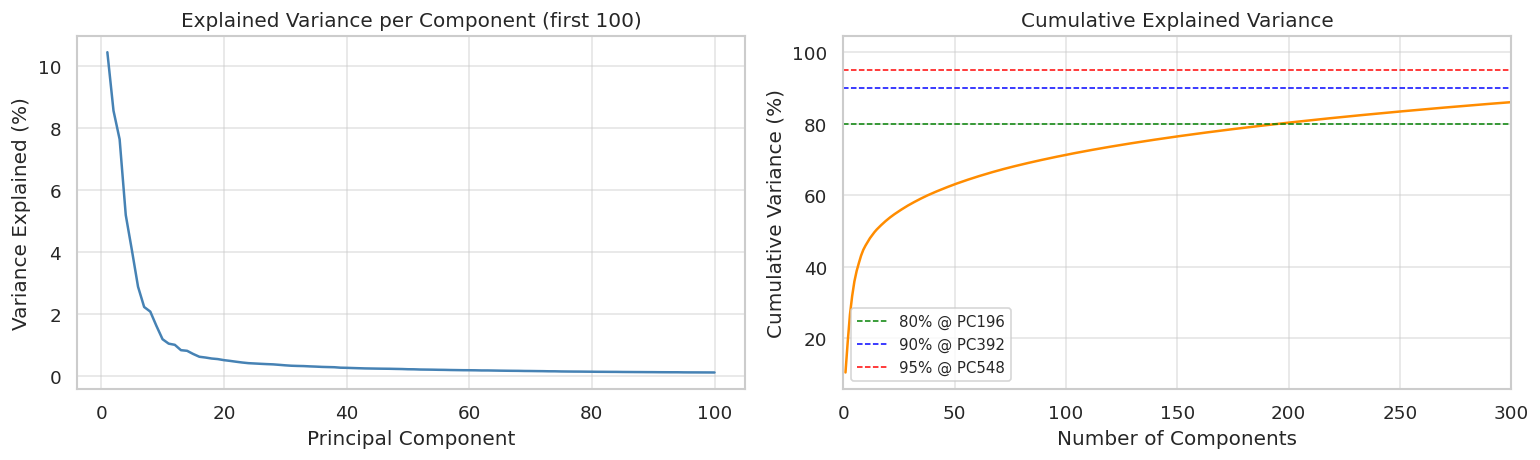

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Individual explained variance (first 100 PCs)
axes[0].plot(range(1, 101), pca_full.explained_variance_ratio_[:100] * 100,
             color="steelblue", linewidth=1.5)
axes[0].set_title("Explained Variance per Component (first 100)")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")

# Cumulative explained variance
axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100,
             color="darkorange", linewidth=1.5)
for thresh, color in [(0.80, "green"), (0.90, "blue"), (0.95, "red")]:
    n = int(np.searchsorted(cumvar, thresh)) + 1
    axes[1].axhline(thresh * 100, linestyle="--", color=color, linewidth=0.9,
                    label=f"{thresh*100:.0f}% @ PC{n}")
axes[1].set_xlim(0, 300)
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/pca_explained_variance.png")
plt.show()

## 6. Fit Final PCA (95% Variance Threshold)

In [24]:
N_COMPONENTS = 0.95   # keep enough PCs to explain 95% of variance

pca    = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca  = pca.fit_transform(X_scaled)

print(f"Components selected : {pca.n_components_}")
print(f"Variance retained   : {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Reduced matrix      : {X_pca.shape}")

Components selected : 548
Variance retained   : 95.01%
Reduced matrix      : (801, 548)


## 7. 2D PCA Projection (Visual Sanity Check)

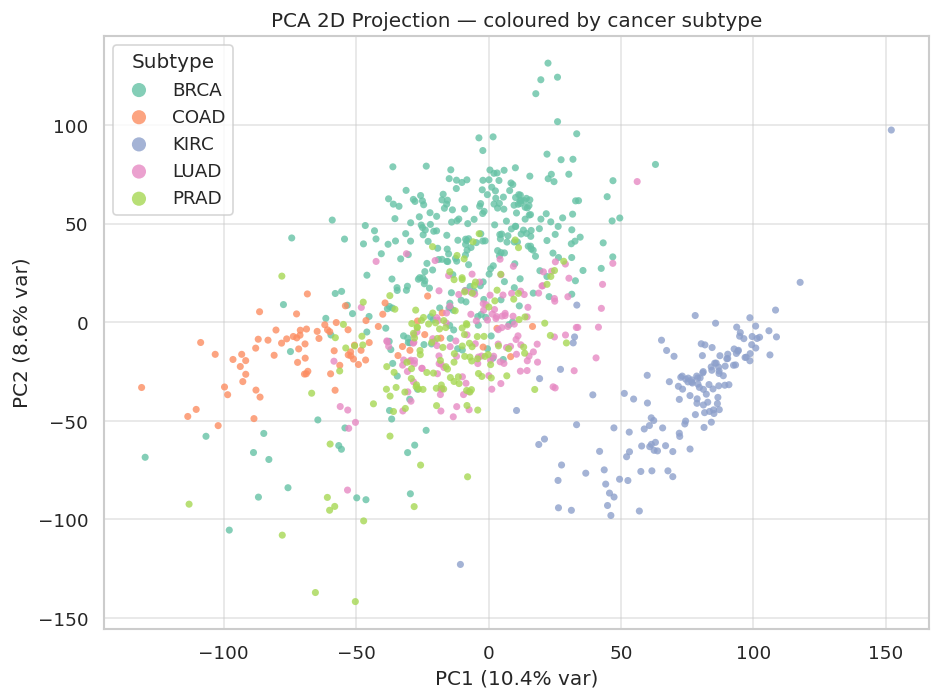

In [25]:
pca2d   = PCA(n_components=2, random_state=42)
X_2d    = pca2d.fit_transform(X_scaled)

palette = sns.color_palette("Set2", labels.nunique())
class_colors = {cls: palette[i] for i, cls in enumerate(sorted(labels.unique()))}

fig, ax = plt.subplots(figsize=(8, 6))
for cls, grp in pd.DataFrame(X_2d, columns=["PC1", "PC2"]).assign(label=labels.values).groupby("label"):
    ax.scatter(grp["PC1"], grp["PC2"], label=cls, s=18, alpha=0.8,
               color=class_colors[cls], edgecolors="none")

ax.set_title("PCA 2D Projection — coloured by cancer subtype")
ax.set_xlabel(f"PC1 ({pca2d.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca2d.explained_variance_ratio_[1]*100:.1f}% var)")
ax.legend(title="Subtype", markerscale=2)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/pca_2d_projection.png")
plt.show()

## 8. Persist Artefacts

In [26]:
# Save scaler and PCA for use in clustering notebook and Streamlit app
joblib.dump(scaler, f"{MODELS_DIR}/scaler.joblib")
joblib.dump(pca,    f"{MODELS_DIR}/pca.joblib")
print("Saved: models/scaler.joblib")
print("Saved: models/pca.joblib")

# Save PCA-reduced matrix and labels for downstream notebooks
pd.DataFrame(X_pca, index=X.index).to_csv(f"{DATA_OUT_DIR}/X_pca.csv")
print("Saved: data/X_pca.csv")

# Also persist the filtered gene list so the app knows which columns to keep
kept_genes = X_filtered.columns.tolist()
pd.Series(kept_genes).to_csv(f"{DATA_OUT_DIR}/kept_genes.csv", index=False, header=["gene"])
print(f"Saved: data/kept_genes.csv  ({len(kept_genes)} genes)")

Saved: models/scaler.joblib
Saved: models/pca.joblib
Saved: data/X_pca.csv
Saved: data/kept_genes.csv  (20264 genes)


## Preprocessing Summary

| Step | Detail |
|---|---|
| Input | 801 samples × 20,531 genes |
| Zero-variance genes removed | see cell 2 output |
| Transform | `log1p` — compresses right-skewed RNA-Seq counts |
| Scaling | `StandardScaler` — zero mean, unit standard deviation per gene |
| PCA threshold | 95% explained variance |
| Output shape | 801 samples × n_components principal components |

**Persisted artefacts**

| File | Contents | Used by |
|---|---|---|
| `models/scaler.joblib` | Fitted `StandardScaler` | Streamlit app (transform new samples) |
| `models/pca.joblib` | Fitted `PCA` | Streamlit app (project new samples) |
| `data/X_pca.csv` | PCA-reduced matrix | Clustering and visualization notebooks |
| `data/kept_genes.csv` | Gene names surviving the zero-variance filter | Streamlit app (validate uploaded files) |

**Next step** — run `03_clustering.ipynb` to apply K-Means and Agglomerative Clustering
to the PCA-reduced feature matrix.